In [1]:
import pandas as pd


sales_stations = pd.read_csv('../../data/Cleared_data/sales_stations.csv', parse_dates=['date', 'created'])
stations = pd.read_csv('../../data/Cleared_data/stations.csv', parse_dates=['created'])
sales= pd.read_csv('../../data/Cleared_data/sales.csv', parse_dates=['date'])

In [2]:
sales_stations

,station_id,date,daily_sales_count,created,partner_name,employee_name,cities
0,1531,2023-07-27,2.0,2023-07-04,МТС,Галина,Курск
1,287,2023-07-29,3.0,2023-07-04,Мегафон,Галина,Московская область
2,340,2023-07-29,2.0,2023-07-04,Мегафон,Роман,Московская область
3,596,2023-07-29,1.0,2023-07-04,Мегафон,Иван,Пермь
4,586,2023-07-30,2.0,2023-07-04,Мегафон,Иван,Екатеринбург
...,...,...,...,...,...,...,...
505371,3918,2026-09-16,1.0,2026-05-22,Beeline,Кирилл,Малый город
505372,3930,2026-09-16,1.0,2026-05-22,Beeline,Кирилл,Томск
505373,3974,2026-09-16,1.0,2026-08-14,Inventive Group,Екатерина,Омск
505374,4001,2026-09-16,2.0,2026-08-25,Inventive Group,Екатерина,Санкт-Петербург


In [3]:
sales_stations.info()

<class 'pandas.DataFrame'>
RangeIndex: 505376 entries, 0 to 505375
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   station_id         505376 non-null  int64         
 1   date               505376 non-null  datetime64[us]
 2   daily_sales_count  505376 non-null  float64       
 3   created            505376 non-null  datetime64[us]
 4   partner_name       505376 non-null  str           
 5   employee_name      505376 non-null  str           
 6   cities             505376 non-null  str           
dtypes: datetime64[us](2), float64(1), int64(1), str(3)
memory usage: 27.0 MB


In [4]:
def full_station(station_id):
    stations_station = stations[stations['id'] == station_id].iloc[0]
    created = stations_station['created']
    partner_name = stations_station['partner_name']
    employee_name = stations_station['employee_name']
    city = stations_station['cities']

    sales_stations_station = sales_stations[sales_stations['station_id'] == station_id]
    last_sale = sales_stations_station['date'].max()

    date_range = pd.date_range(start=created, end=last_sale, freq='D').date

    # приводим ключи словаря к date, а не Timestamp
    sales_by_date = (
        sales_stations_station
        .assign(date=sales_stations_station['date'].dt.date)
        .set_index('date')['daily_sales_count']
        .to_dict()
    )

    rows = []
    for date_ in date_range:
        rows.append({
            'station_id': station_id,
            'date': date_,
            'daily_sales_count': sales_by_date.get(date_, 0),
            'created': created,
            'partner_name': partner_name,
            'employee_name': employee_name,
            'cities': city
        })

    answer = pd.DataFrame(rows)
    return answer


In [5]:
sparse_sales_stations = pd.concat(
    [full_station(sid) for sid in stations['id'].unique()],
    ignore_index=True
)

In [6]:
sparse_sales_stations

,station_id,date,daily_sales_count,created,partner_name,employee_name,cities
0,277,2023-07-04,0.0,2023-07-04,Мегафон,Екатерина,Санкт-Петербург
1,277,2023-07-05,0.0,2023-07-04,Мегафон,Екатерина,Санкт-Петербург
2,277,2023-07-06,0.0,2023-07-04,Мегафон,Екатерина,Санкт-Петербург
3,277,2023-07-07,0.0,2023-07-04,Мегафон,Екатерина,Санкт-Петербург
4,277,2023-07-08,0.0,2023-07-04,Мегафон,Екатерина,Санкт-Петербург
...,...,...,...,...,...,...,...
1483917,4052,2026-09-12,0.0,2026-09-11,Inventive Group,Никита,Москва
1483918,4052,2026-09-13,3.0,2026-09-11,Inventive Group,Никита,Москва
1483919,4054,2026-09-11,2.0,2026-09-11,Inventive Group,Никита,Москва
1483920,4055,2026-09-11,5.0,2026-09-11,Inventive Group,Никита,Москва


### Построим графики продаж для некоторых станций

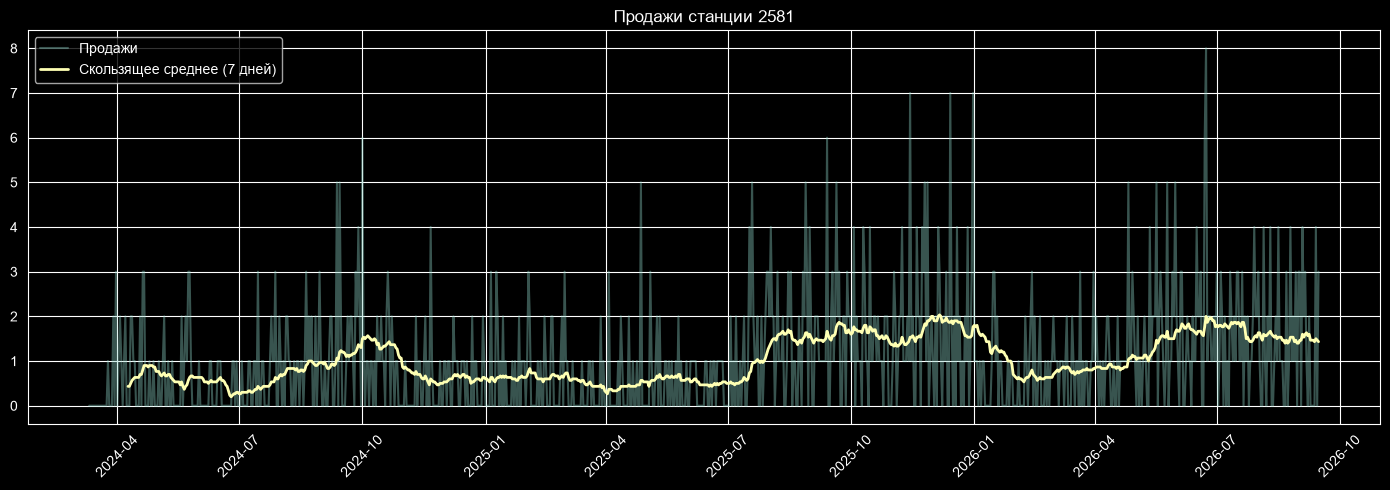

In [7]:
import matplotlib.pyplot as plt

df = full_station(2581).sort_values('date')
df['rolling_7'] = df['daily_sales_count'].rolling(window=30).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['daily_sales_count'], label='Продажи', alpha=0.4)
plt.plot(df['date'], df['rolling_7'], label='Скользящее среднее (7 дней)', linewidth=2)
plt.legend()
plt.title('Продажи станции 2581')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()